=== SVM ===
              precision    recall  f1-score   support

         0.0       0.83      0.82      0.83       124
         1.0       0.77      0.78      0.77        94

    accuracy                           0.80       218
   macro avg       0.80      0.80      0.80       218
weighted avg       0.80      0.80      0.80       218

Accuracy: 0.8027522935779816


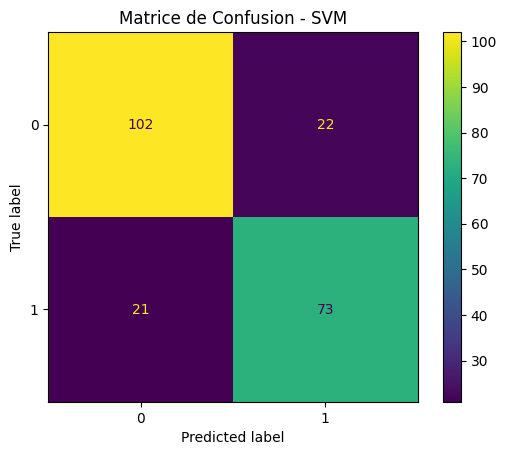

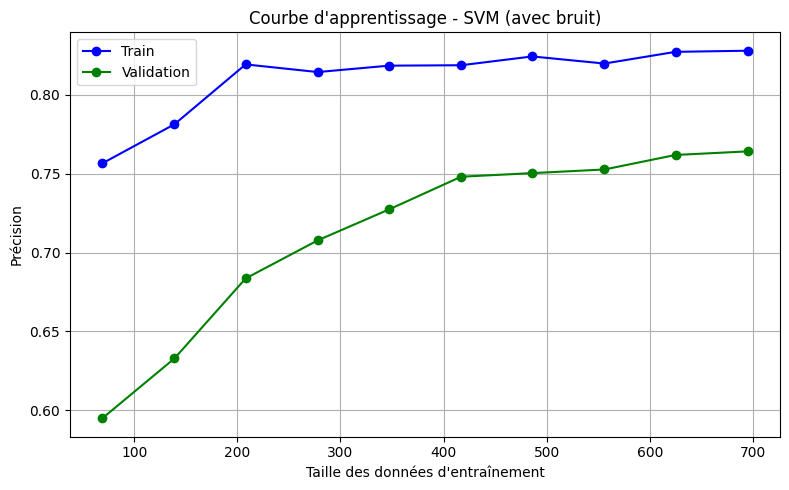

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv("missions_fusionnees.csv")

X = df.drop(columns=["is_attack"])
y = df["is_attack"]

X = X.fillna(X.mean(numeric_only=True))

idx_shuffle = X.sample(frac=0.25, random_state=2).index
X.loc[idx_shuffle] = X.loc[idx_shuffle].sample(frac=1, random_state=2).values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = StandardScaler().fit(X_train).transform(X_test) 

svm = SVC(kernel='rbf', C=0.6, gamma='scale')  
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)

print("=== SVM ===")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Matrice de Confusion - SVM")
plt.show()

train_sizes, train_scores, test_scores = learning_curve(
    svm, X_train_scaled, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Train", color='blue')
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Validation", color='green')
plt.title("Courbe d'apprentissage - SVM ")
plt.xlabel("Taille des données d'entraînement")
plt.ylabel("Précision")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


In [2]:
import joblib

joblib.dump(svm, "SVM_21.pkl")

['SVM_21.pkl']